In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

#DATA PreProcessing

In [5]:
#Handle Missing Value

In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median())

 Feature Engineering

In [7]:
#Age
df["Age"]=2026-df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [9]:
#Spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [11]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
#Education
df["Education"].value_counts()
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [14]:
df["Education"].value_counts()

Education
graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [16]:
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "YOLO":"Alone",
    "Absurd":"Alone"
})

In [17]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


DROP COLUMNS

In [19]:
cols=["ID","Year_Birth","Kidhome","Marital_Status","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [20]:
cols_to_drop=cols+spending_cols

In [21]:
df_cleaned=df.drop(columns=cols_to_drop)

In [22]:
df_cleaned.shape

(2240, 15)

In [23]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


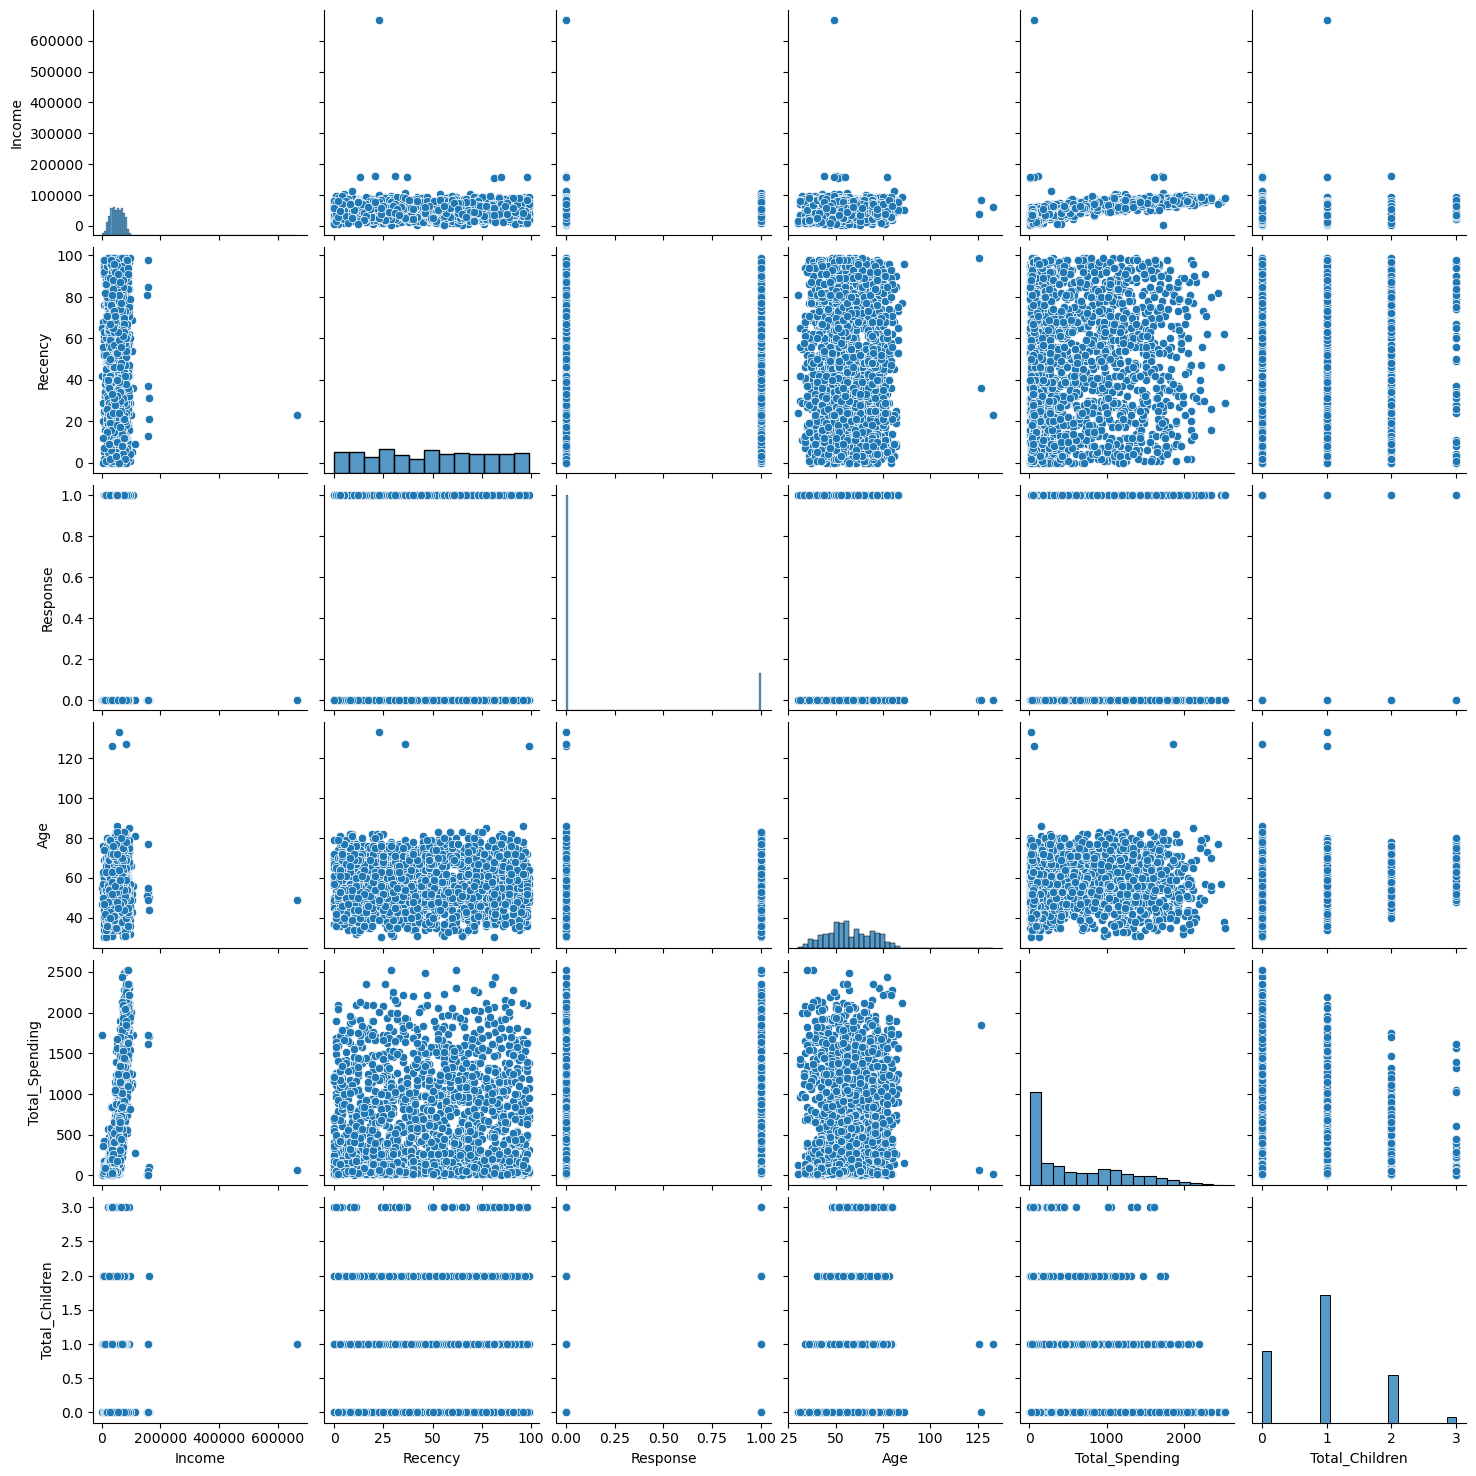

In [26]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
#Relative Plots of some features
sns.pairplot(df_cleaned[cols])

In [28]:
print("Datasize size with outliers: ",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("Datasize size without outliers: ",len(df_cleaned))

Datasize size with outliers:  2240
Datasize size without outliers:  2236


<Axes: >

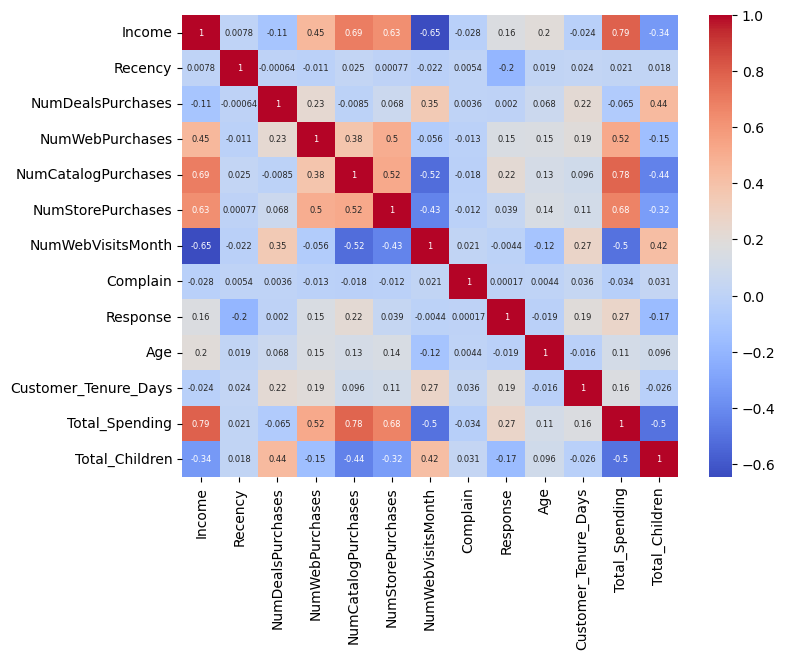

In [34]:
#HeatMaps
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [35]:
df_cleaned.shape

(2236, 15)

In [36]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [37]:
#Feature Encoding

In [38]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [42]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [43]:
enc_df.head()

,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner
0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0


In [45]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [46]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,0.0,1.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,0.0,1.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,0.0,1.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,0.0,1.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1.0,0.0,0.0,0.0,1.0


In [50]:
X=df_encoded

In [48]:
#Scaling

In [53]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [54]:
#Visualize Data

In [55]:
X_scaled.shape

(2236, 18)

In [56]:
#2D
from sklearn.decomposition import PCA

In [66]:
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Figure')

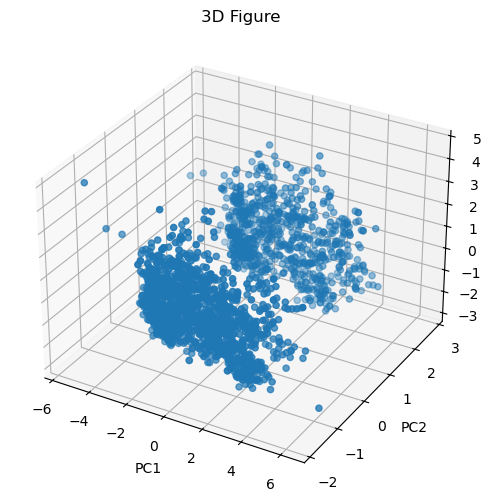

In [74]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Figure")

In [75]:
#Analyze the value of clusters
#1 Elbow Method

In [76]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [79]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
Optimal_K=knee.elbow

In [80]:
print("Best K= ",Optimal_K)

Best K=  4


Text(0, 0.5, 'Wcss')

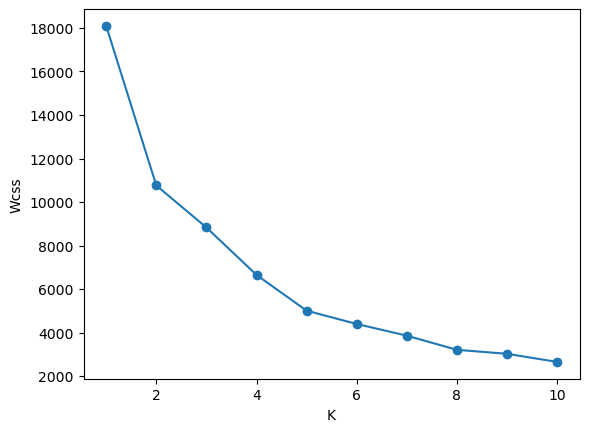

In [84]:
plt.plot(range(1,11),wcss,marker='o',)
plt.xlabel("K")
plt.ylabel("Wcss")

In [85]:
#Silhouette Score

In [86]:
from sklearn.metrics import silhouette_score

Text(0, 0.5, 'Score')

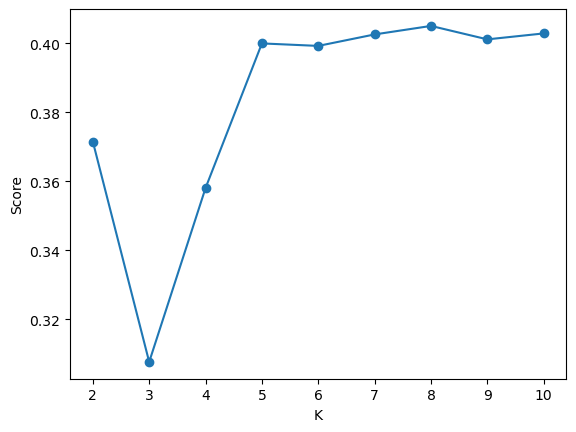

In [89]:
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Score")

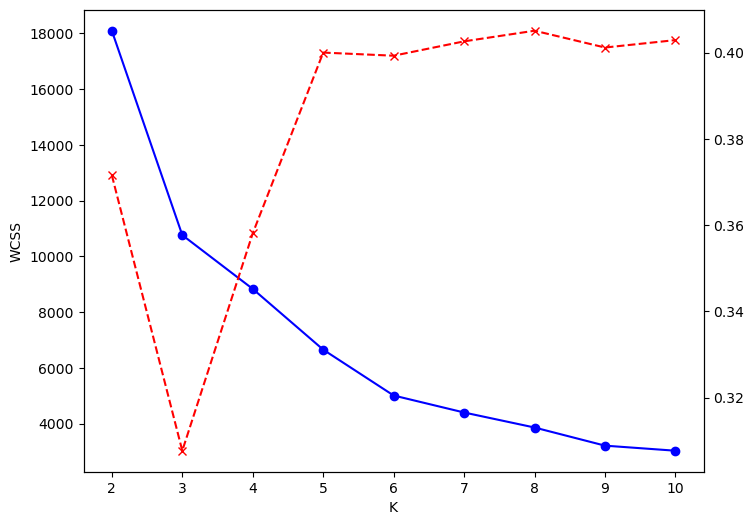

In [96]:
#combined Plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")

In [106]:
#Clustering 
#KMeans


Text(0.5, 0.92, '3D Figure')

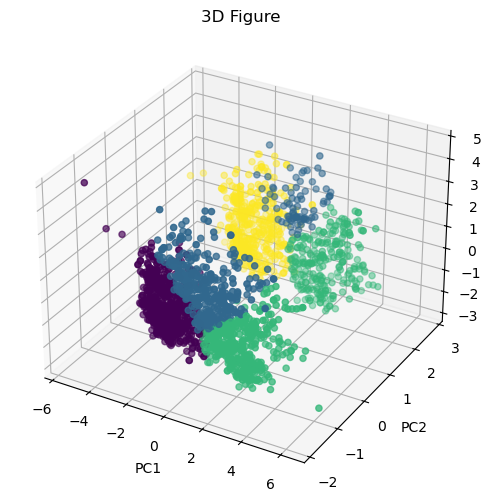

In [103]:
kmeans=KMeans(n_clusters=4,random_state=42)
lables_kmeans=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=lables_kmeans)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Figure")

In [107]:
#Agglomerative
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")

Text(0.5, 0.92, '3D Figure')

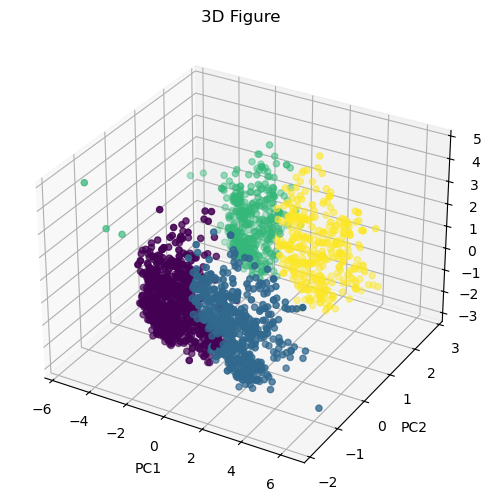

In [105]:
labels_agg=agg_clf.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Figure")

In [123]:
X["clusters"]=labels_agg

In [124]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Postgraduate,Education_Undergraduate,Education_graduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,0.0,1.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,0.0,1.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,0.0,1.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,0.0,1.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

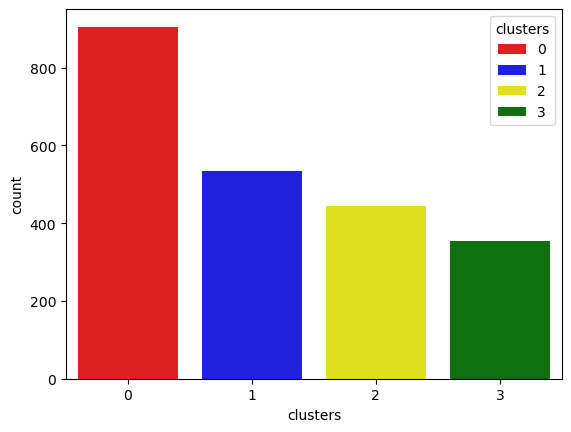

In [125]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

In [126]:
#Income and Spending Patterns

<Axes: xlabel='Total_Spending', ylabel='Income'>

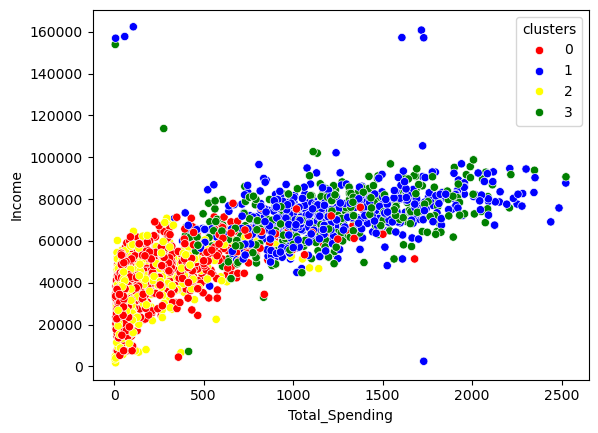

In [127]:
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [122]:
#Cluster Summary

In [129]:
cluster_summary=X.groupby("clusters").mean()

In [130]:
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu